# Titanic: Práce s daty

Kompletní pipeline datové analýzy a strojového učení na datasetu z katastrofy lodi Titanic.

Části:
1. Průzkumová analýza dat (EDA)
2. Předzpracování dat
3. Klasifikační modely (Decision Tree, Random Forest, Neural Network, AdaBoost)

In [123]:
!pip install numpy pandas matplotlib seaborn scikit-learn torch

In [124]:
import os

os.makedirs('results', exist_ok=True)

---

# Titanic: Průzkumová analýza dat (EDA)

Dataset z katastrofy lodi [Titanic](https://www.kaggle.com/c/titanic).
Cílem je na základě informací o pasažérech predikovat, zda přežili nebo nepřežili.

In [125]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Načtení dat

In [126]:
train = pd.read_csv('../data/train.csv')
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Popis sloupců

| Sloupec | Popis |
|---------|-------|
| **PassengerId** | Unikátní ID pasažéra |
| **Survived** | 0 = Nepřežil, 1 = Přežil |
| **Pclass** | Třída cestovního lístku (1 = 1., 2 = 2., 3 = 3.) |
| **Name** | Jméno pasažéra |
| **Sex** | Pohlaví (male, female) |
| **Age** | Věk v letech |
| **SibSp** | Počet sourozenců / manželů/manželek na palubě |
| **Parch** | Počet rodičů / dětí na palubě |
| **Ticket** | Číslo lístku |
| **Fare** | Cena jízdenky |
| **Cabin** | Číslo kajuty |
| **Embarked** | Přístav nalodění (C = Cherbourg, Q = Queenstown, S = Southampton) |

Zdroj: [Kaggle](https://www.kaggle.com/c/titanic/data)

## Vizualizace

### Distribuce cílové proměnné

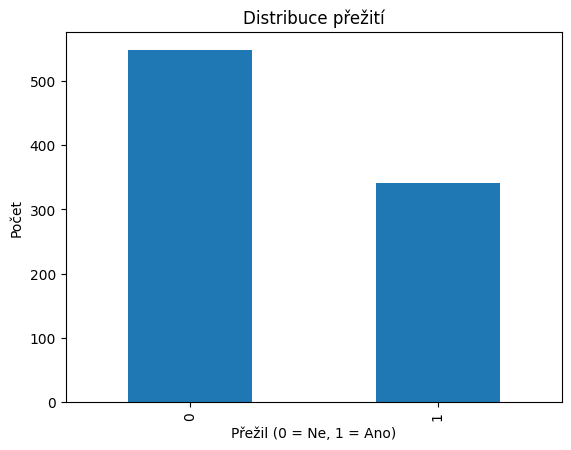

In [127]:
train['Survived'].value_counts().plot(kind='bar')
plt.title('Distribuce přežití')
plt.xlabel('Přežil (0 = Ne, 1 = Ano)')
plt.ylabel('Počet')
plt.show()

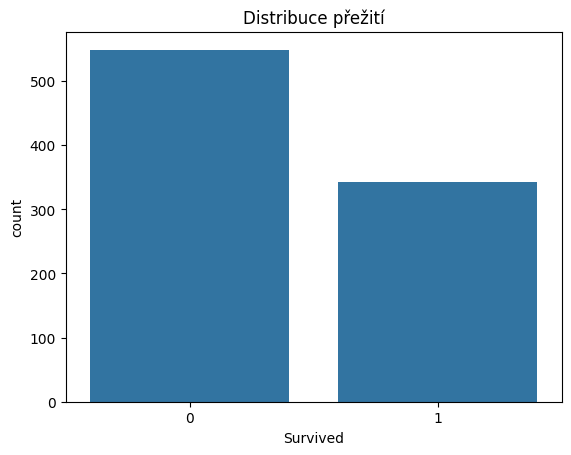

In [128]:
# Totéž pomocí seaborn
sns.countplot(x='Survived', data=train)
plt.title('Distribuce přežití')
plt.show()

### Přežití podle třídy

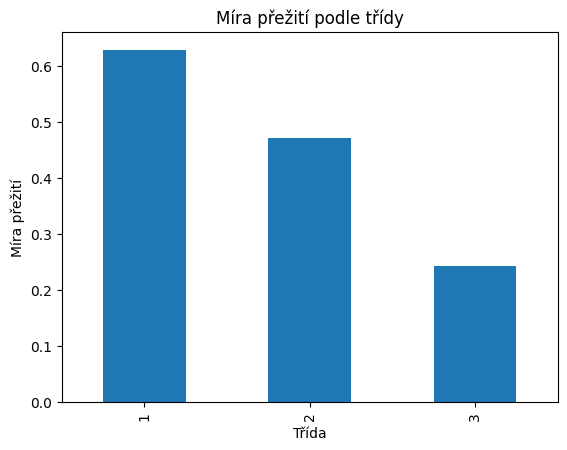

In [129]:
train.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title('Míra přežití podle třídy')
plt.xlabel('Třída')
plt.ylabel('Míra přežití')
plt.show()

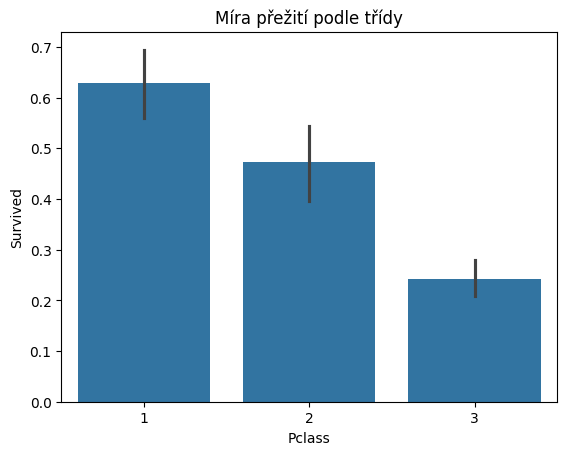

In [130]:
sns.barplot(x='Pclass', y='Survived', data=train)
plt.title('Míra přežití podle třídy')
plt.show()

### Přežití podle pohlaví

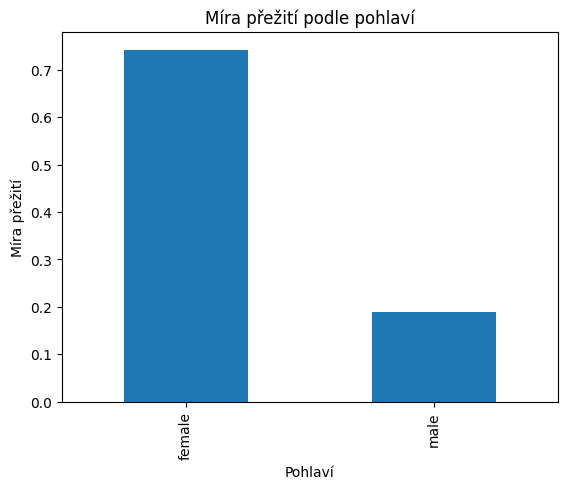

In [131]:
train.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Míra přežití podle pohlaví')
plt.xlabel('Pohlaví')
plt.ylabel('Míra přežití')
plt.show()

### Distribuce věku podle přežití

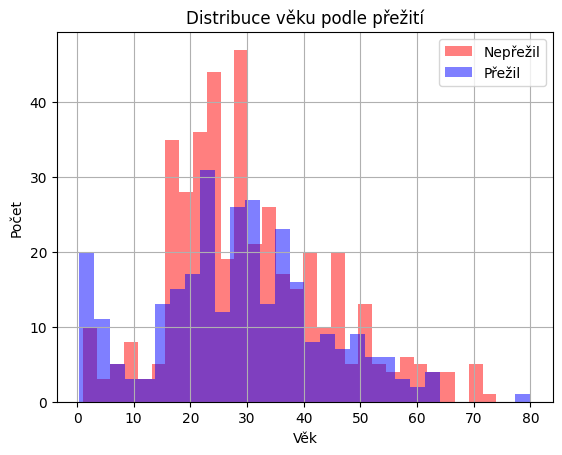

In [132]:
train[train['Survived'] == 0]['Age'].hist(bins=30, alpha=0.5, color='red', label='Nepřežil')
train[train['Survived'] == 1]['Age'].hist(bins=30, alpha=0.5, color='blue', label='Přežil')
plt.title('Distribuce věku podle přežití')
plt.xlabel('Věk')
plt.ylabel('Počet')
plt.legend()
plt.show()

### Přežití podle počtu sourozenců/partnerů (SibSp)

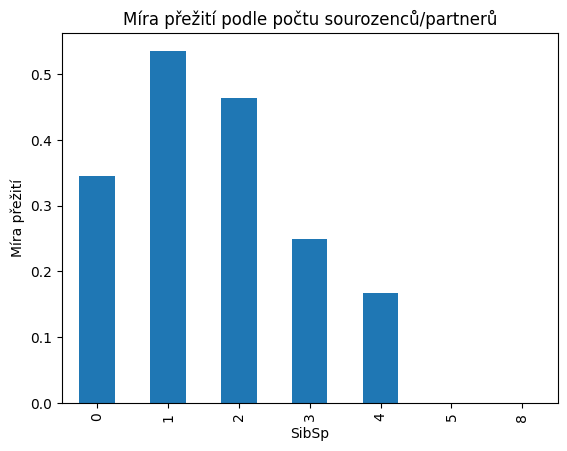

In [133]:
train.groupby('SibSp')['Survived'].mean().plot(kind='bar')
plt.title('Míra přežití podle počtu sourozenců/partnerů')
plt.xlabel('SibSp')
plt.ylabel('Míra přežití')
plt.show()

### Přežití podle počtu rodičů/dětí (Parch)

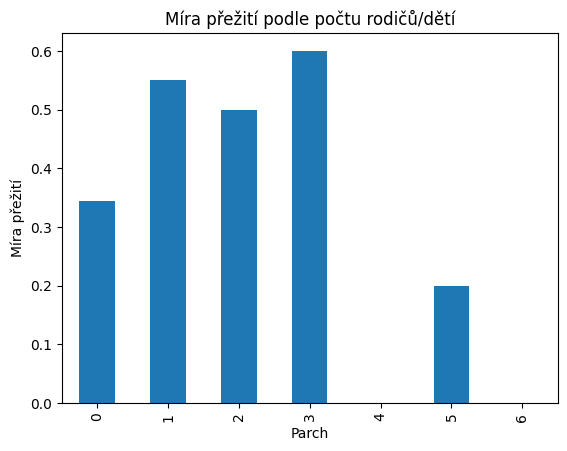

In [134]:
train.groupby('Parch')['Survived'].mean().plot(kind='bar')
plt.title('Míra přežití podle počtu rodičů/dětí')
plt.xlabel('Parch')
plt.ylabel('Míra přežití')
plt.show()

### Distribuce ceny jízdenky podle přežití

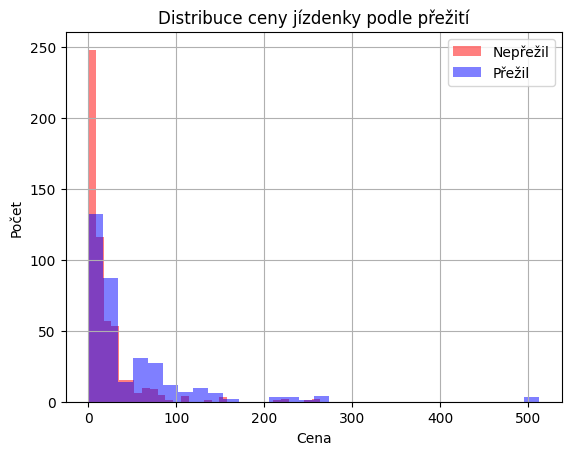

In [135]:
train[train['Survived'] == 0]['Fare'].hist(bins=30, alpha=0.5, color='red', label='Nepřežil')
train[train['Survived'] == 1]['Fare'].hist(bins=30, alpha=0.5, color='blue', label='Přežil')
plt.title('Distribuce ceny jízdenky podle přežití')
plt.xlabel('Cena')
plt.ylabel('Počet')
plt.legend()
plt.show()

### Kajuta a přežití

In [136]:
train['Cabin'].isna().sum()

np.int64(687)

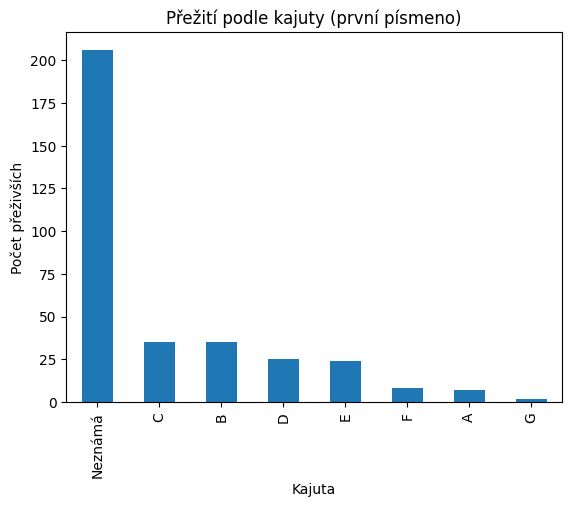

In [137]:
train[train['Survived'] == 1]['Cabin'].str[0].fillna('Neznámá').value_counts().plot(kind='bar')
plt.title('Přežití podle kajuty (první písmeno)')
plt.xlabel('Kajuta')
plt.ylabel('Počet přeživších')
plt.show()

### Přežití podle přístavu nalodění

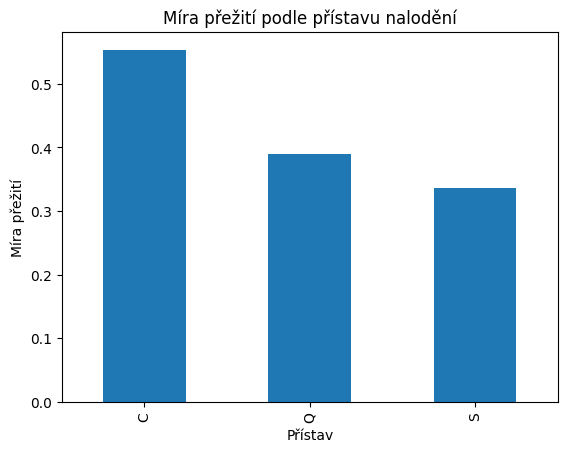

In [138]:
train.groupby('Embarked')['Survived'].mean().plot(kind='bar')
plt.title('Míra přežití podle přístavu nalodění')
plt.xlabel('Přístav')
plt.ylabel('Míra přežití')
plt.show()

---

# Titanic: Předzpracování dat

Než začneme trénovat modely, musíme data připravit — odstranit nepotřebné sloupce,
zpracovat chybějící hodnoty a zakódovat kategorické proměnné.

## Rozdělení na trénovací a testovací data

- **Trénovací data (train)** — na těchto datech model trénujeme, známe správné odpovědi
- **Testovací data (test)** — na těchto datech model vyhodnocujeme, neznáme správné odpovědi

![Train-Test split](../img/train-test-split.jpg)

Zdroj: [builtin.com](https://builtin.com/data-science/train-test-split)

In [139]:
# Znovu načteme data (čistá kopie)
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

len(train), len(test)

(891, 418)

## Odstranění nepotřebných sloupců

In [140]:
# Z trénovacích dat odstraníme PassengerId, Name, Ticket, Cabin
train = train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Z testovacích dat ponecháme PassengerId (potřebujeme ho pro submission)
test = test.drop(columns=['Name', 'Ticket', 'Cabin'])

train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


## Zpracování chybějících hodnot

In [141]:
# Které sloupce mají chybějící hodnoty?
print("Trénovací data:")
print(train.isnull().sum())
print()
print("Testovací data:")
print(test.isnull().sum())

Trénovací data:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Testovací data:
PassengerId     0
Pclass          0
Sex             0
Age            86
SibSp           0
Parch           0
Fare            1
Embarked        0
dtype: int64


Chybějící hodnoty můžeme:
- **odstranit** — smazat řádky s chybějícími hodnotami
- **doplnit** — nahradit průměrem (mean), mediánem (median) nebo nejčastější hodnotou (mode)

In [142]:
train['Age'].mean()

np.float64(29.69911764705882)

In [143]:
# mode() vrátí Series s nejčastější hodnotou
train['Embarked'].mode()

0    S
Name: Embarked, dtype: str

In [144]:
# Doplnění chybějících hodnot v trénovacích datech
train['Age'] = train['Age'].fillna(train['Age'].mean())
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# Doplnění chybějících hodnot v testovacích datech
test['Age'] = test['Age'].fillna(test['Age'].mean())
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

In [145]:
# Ověření — žádné chybějící hodnoty
print("Trénovací data:")
print(train.isnull().sum())
print()
print("Testovací data:")
print(test.isnull().sum())

Trénovací data:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Testovací data:
PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


## Kódování kategorických proměnných

Modely strojového učení vyžadují numerický vstup.
Kategorické sloupce musíme převést na čísla.

In [146]:
# Které sloupce jsou kategorické?
train.dtypes

Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked        str
dtype: object

Použijeme **one-hot encoding** — pro každou kategorii vytvoříme nový binární sloupec.

In [147]:
train = pd.get_dummies(train, columns=["Sex", "Embarked"])
test = pd.get_dummies(test, columns=["Sex", "Embarked"])

train

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,7.2500,False,True,False,False,True
1,1,1,38.000000,1,0,71.2833,True,False,True,False,False
2,1,3,26.000000,0,0,7.9250,True,False,False,False,True
3,1,1,35.000000,1,0,53.1000,True,False,False,False,True
4,0,3,35.000000,0,0,8.0500,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,False,True,False,False,True
887,1,1,19.000000,0,0,30.0000,True,False,False,False,True
888,0,3,29.699118,1,2,23.4500,True,False,False,False,True
889,1,1,26.000000,0,0,30.0000,False,True,True,False,False


---

# Titanic: Klasifikační modely

![Typy klasifikačních modelů](../img/classification-model-types.jpg)

Zdroj: [datacamp.com](https://www.datacamp.com/tutorial/adaboost-classifier-python)

## Příprava dat pro trénování

In [148]:
X = train.drop(columns='Survived')
y = train['Survived']

print(f"Počet features: {X.shape[1]}")
print(f"Features: {list(X.columns)}")

Počet features: 10
Features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


## Náhodný klasifikátor (Random Classifier)

Baseline — model, který predikuje náhodně. Očekávaná přesnost ~50 %.

In [149]:
submission_random = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': np.random.randint(0, 2, size=len(test))
})

submission_random.head()

submission_random.to_csv('results/submission_random.csv', index=False)


## Rozhodovací strom (Decision Tree)

Rozděluje data na základě podmínek do větví, dokud nedosáhne listů s finální predikcí.

In [150]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

decision_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

decision_tree.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

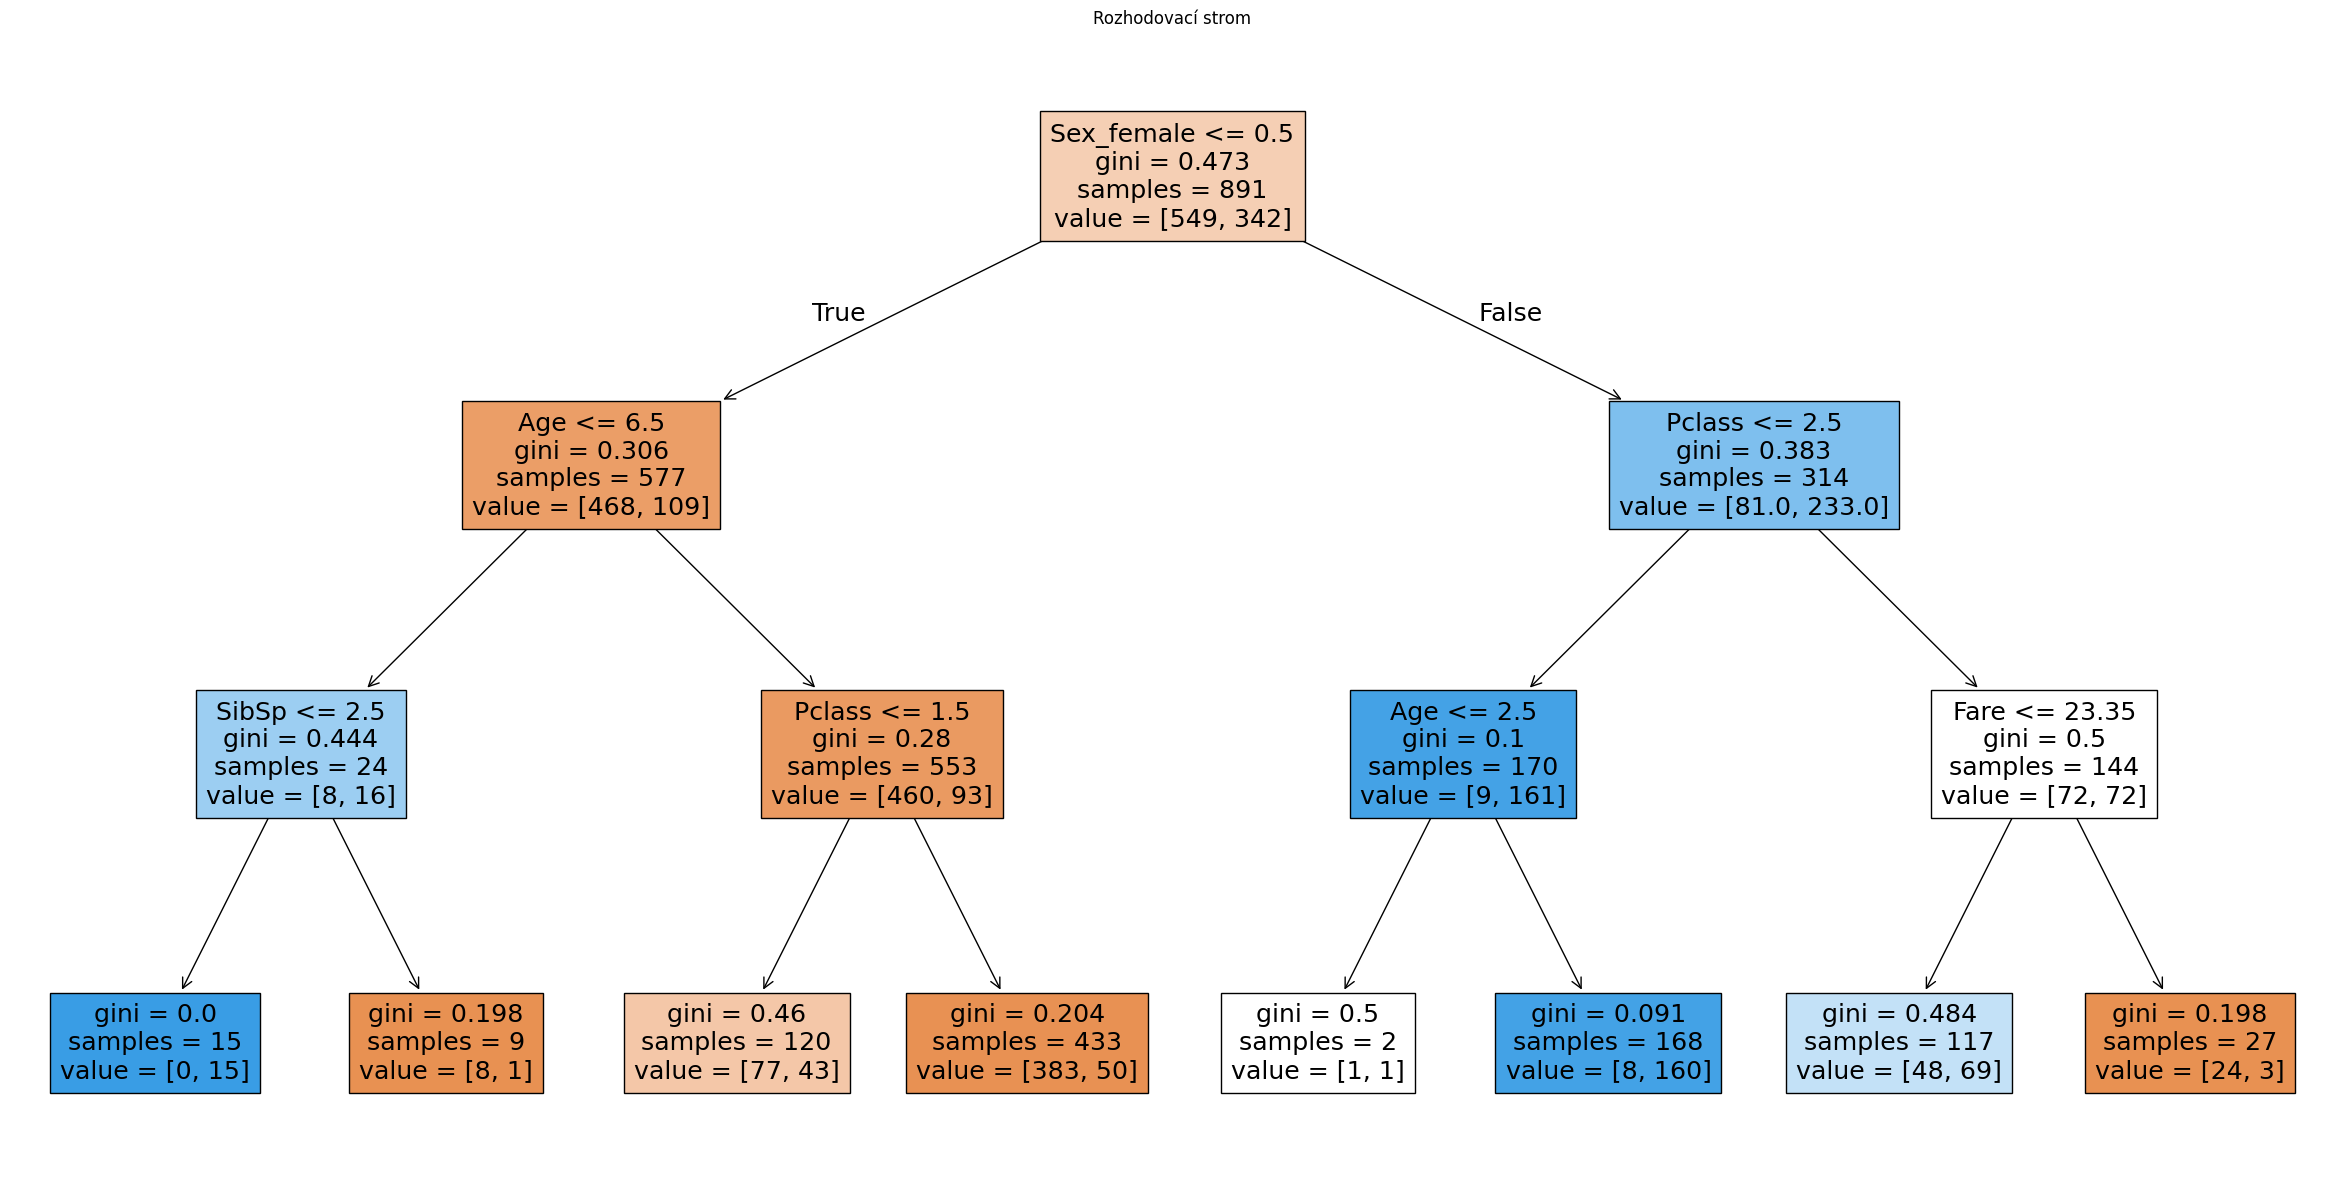

In [151]:
# Vizualizace rozhodovacího stromu
plt.figure(figsize=(30, 15))
plot_tree(decision_tree, feature_names=X.columns, filled=True)
plt.title('Rozhodovací strom')
plt.show()

In [152]:
# Predikce na testovacích datech
y_pred = decision_tree.predict(test.drop(columns=['PassengerId']))
y_pred[:10]

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0])

In [153]:
submission_decision_tree = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred
})

submission_decision_tree.head()

submission_decision_tree.to_csv('results/submission_decision_tree.csv', index=False)


## Náhodný les (Random Forest)

Ensemble metoda — kombinuje mnoho rozhodovacích stromů,
výslednou predikci určuje většinovým hlasováním.

In [154]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

random_forest.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [155]:
y_pred = random_forest.predict(test.drop(columns=['PassengerId']))

submission_random_forest = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred
})

submission_random_forest.head()

submission_random_forest.to_csv('results/submission_random_forest.csv', index=False)


## Neuronová síť (PyTorch)

In [156]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [157]:
# Převod na PyTorch tensory
X_tensor = torch.tensor(X.astype('float32').values)
y_tensor = torch.tensor(y.values).reshape(-1, 1).float()

print(f"X shape: {X_tensor.shape}")
print(f"y shape: {y_tensor.shape}")

X shape: torch.Size([891, 10])
y shape: torch.Size([891, 1])


In [158]:
# Definice neuronové sítě
class NeuralNetwork(nn.Module):
    def __init__(self, input_size=10):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

In [159]:
# Vytvoření modelu
model = NeuralNetwork(input_size=X_tensor.shape[1])

# Loss funkce a optimizér
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [160]:
# DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [161]:
import copy

# Trénování
best_model = None
best_loss = float('inf')

for epoch in range(1000):
    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_model = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch + 1}/1000, Loss: {loss.item():.4f}')

print(f'\nNejlepší loss: {best_loss:.4f}')

Epoch 100/1000, Loss: 0.4559
Epoch 200/1000, Loss: 0.3173
Epoch 300/1000, Loss: 0.3006
Epoch 400/1000, Loss: 0.2395
Epoch 500/1000, Loss: 0.2136
Epoch 600/1000, Loss: 0.3133
Epoch 700/1000, Loss: 0.3549
Epoch 800/1000, Loss: 0.2501
Epoch 900/1000, Loss: 0.1567
Epoch 1000/1000, Loss: 0.3759

Nejlepší loss: 0.0461


In [162]:
# Predikce na testovacích datech
model.load_state_dict(best_model)

test_X_tensor = torch.tensor(
    test.drop(columns='PassengerId').astype('float32').values
)

y_pred = model(test_X_tensor)
y_pred = (y_pred > 0.5).float()
y_pred = y_pred.detach().numpy().reshape(-1)

submission_neural_network = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred.astype(int)
})

submission_neural_network.head()

submission_neural_network.to_csv('results/submission_neural_network.csv', index=False)


---

# Pokročilé modely (Bonus)

## AdaBoost

Adaptive Boosting — ensemble metoda, která postupně trénuje slabé klasifikátory
a přidává jim váhu podle toho, jak dobře klasifikují obtížné příklady.

In [163]:
from sklearn.ensemble import AdaBoostClassifier

adaboost = AdaBoostClassifier(
    n_estimators=100,
    random_state=42,
)

adaboost.fit(X, y)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [164]:
y_pred = adaboost.predict(test.drop(columns=['PassengerId']))

submission_adaboost = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred
})

submission_adaboost.head()

submission_adaboost.to_csv('results/submission_adaboost.csv', index=False)


## AdaBoost + SVC

AdaBoost kombinovaný s Support Vector Classifier jako základním klasifikátorem.

In [165]:
from sklearn.svm import SVC

adaboost_svc = AdaBoostClassifier(
    estimator=SVC(probability=True),
    n_estimators=100,
    random_state=42,
)

adaboost_svc.fit(X, y)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",SVC(probability=True)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True


In [ ]:
y_pred = adaboost_svc.predict(test.drop(columns=['PassengerId']))

submission_adaboost_svc = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred
})

submission_adaboost_svc.head()

submission_adaboost_svc.to_csv('results/submission_adaboost_svc.csv', index=False)